In [1]:
import numpy as np
from matplotlib import pyplot as plt
import qutip as qt
from scipy.integrate import quad
from scipy.linalg import eigh
from scipy import interpolate as interp

In [2]:
# Parameters
N_res = 4
N_input = 4
N_output =4
kappa_ext0 = 1
kappa_p = 1.5 * kappa_ext0
sigma = 1. / kappa_ext0
t_center = 4. / kappa_ext0
delta = 0
tList = np.linspace(0, 15 / kappa_ext0, 100)

# Operators
c = qt.destroy(N_res)
cd = c.dag()
au = qt.destroy(N_input)
aud = au.dag()
# av = qt.destroy(N_output)
# avd = au.dag()

ID_input = qt.identity(N_input)
ID_res = qt.identity(N_res)
# ID_output = qt.identity(N_output)

au_input = qt.tensor([au, ID_res])#, ID_output])
aud_input = au_input.dag()
c_res = qt.tensor([ID_input, c])#, ID_output])
cd_res = c_res.dag()
# av_input = qt.tensor([au, ID_res, av])
# avd_input = av_input.dag()


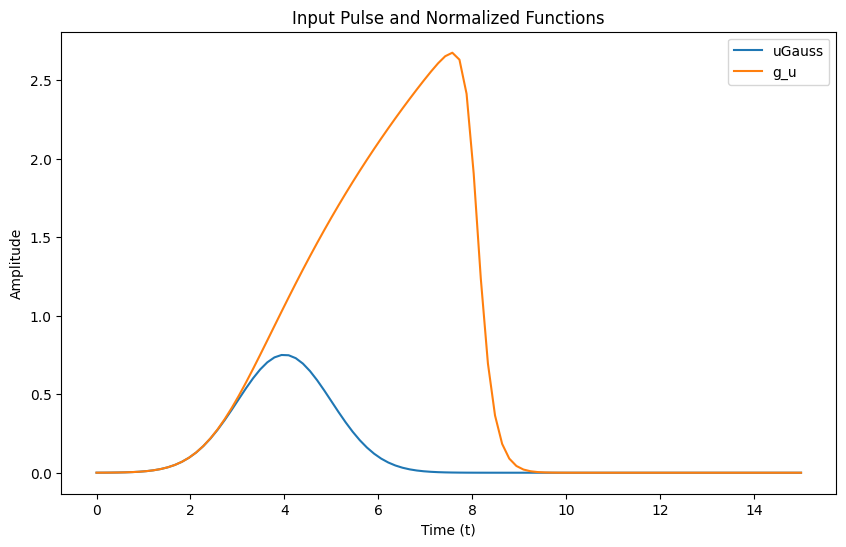

In [58]:
# Input pulse functions
def uGauss(t, args):
    tCenter = args['tCenter']
    sigma = args['sigma']
    prefactor = 1. / (np.sqrt(sigma) * (np.pi ** (1. / 4)))
    return prefactor * np.exp(-((t - tCenter) ** 2) / (2 * sigma ** 2))

def g_u(ts, args):
    ut = lambda t: args['driveFunc'](t, args['driveFuncArgs'])
    eps = 1e-14
    
    denom = quad(lambda t: np.abs(ut(t)) ** 2, tList[0], ts)[0]
    denomtot = np.sqrt(1 - denom + eps)

    return np.conjugate(ut(ts)) / denomtot

# Drive function arguments
driveFuncArgs = {'tCenter': t_center, 'sigma': sigma}
args = {
    'kappa_ext0': kappa_ext0,
    'kappa_p': kappa_p,
    'driveFunc': uGauss,
    'driveFuncArgs': driveFuncArgs
}

# Visualization of pulses
plt.figure(figsize=(10, 6))
plt.plot(tList, uGauss(tList, driveFuncArgs), label='uGauss')
plt.plot(tList, [g_u(t, args) for t in tList], label='g_u')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.title('Input Pulse and Normalized Functions')
plt.legend()
plt.show()

calc the state of a quantum system

In [59]:
# Hamiltonians
H_s = delta * cd_res * c_res
H_d_dag = 0.5j * np.sqrt(kappa_ext0) * aud_input * c_res
H_d = -0.5j * np.sqrt(kappa_ext0) * au_input * cd_res
H_us = [H_s, [H_d_dag, lambda t:g_u(t, args)], [H_d, lambda t: np.conjugate(g_u(t, args))]]

# Collapse operators
def sqrt_kappa_constant(t, args):
    return np.sqrt(args['kappa_ext0'])

c_ops = [
    np.sqrt(args['kappa_p']) * cd_res * c_res,
    [c_res, lambda t: sqrt_kappa_constant(t, args)],
    [au_input, lambda t: g_u(t, args)]
]

# Initial state
psi0 = qt.tensor(qt.basis(N_input, 1), qt.basis(N_res, 0))

# Options for mesolve
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=5000, max_step=0.1, store_states=True)

# Solving the system
result = qt.mesolve(H_us, psi0, tList, c_ops, [], options=options, progress_bar=True, args=args)

10.1%. Run time:   0.05s. Est. time left: 00:00:00:00
20.2%. Run time:   0.10s. Est. time left: 00:00:00:00
30.3%. Run time:   0.18s. Est. time left: 00:00:00:00


c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


40.4%. Run time:   0.28s. Est. time left: 00:00:00:00
50.5%. Run time:   0.37s. Est. time left: 00:00:00:00
60.6%. Run time:   0.47s. Est. time left: 00:00:00:00
70.7%. Run time:   0.53s. Est. time left: 00:00:00:00
80.8%. Run time:   0.60s. Est. time left: 00:00:00:00
90.9%. Run time:   0.67s. Est. time left: 00:00:00:00
100.0%. Run time:   0.72s. Est. time left: 00:00:00:00
Total run time:   0.72s


c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


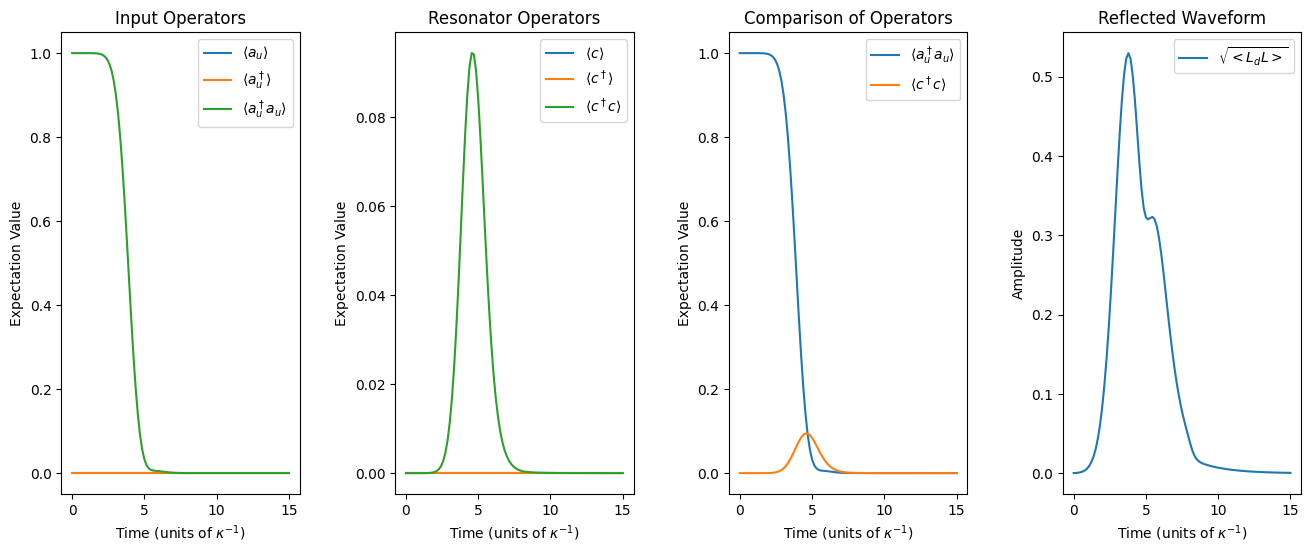

In [60]:
# Extract states
states = result.states

# Input operators
au_s = qt.expect(au_input, states)
aud_s = qt.expect(aud_input, states)
audau_s = qt.expect(aud_input * au_input, states)

# Resonator operators
c_s = qt.expect(c_res, states)
cd_s = qt.expect(cd_res, states)
cdc_s = qt.expect(cd_res * c_res, states)

# Cross terms
audc_s = qt.expect(aud_input * c_res, states)
cdau_s = qt.expect(cd_res * au_input, states)

# Lindblad term
gu_values = np.array([g_u(t, args) for t in tList])
LdL = (
    gu_values * np.conjugate(gu_values) * audau_s
    + kappa_ext0 * cdc_s
    + np.sqrt(kappa_ext0) * (gu_values * audc_s + np.conjugate(gu_values) * cdau_s)
)


fig, axes = plt.subplots(1, 4, figsize=(16, 6))
plt.subplots_adjust(wspace=0.4)

# Input operators
axes[0].plot(tList, au_s, label=r"$\langle a_u \rangle$")
axes[0].plot(tList, aud_s, label=r"$\langle a_u^\dagger \rangle$")
axes[0].plot(tList, audau_s, label=r"$\langle a_u^\dagger a_u \rangle$")
axes[0].legend()
axes[0].set_title("Input Operators")
axes[0].set_xlabel(r"Time (units of $\kappa^{-1}$)")
axes[0].set_ylabel("Expectation Value")

# Resonator operators
axes[1].plot(tList, c_s, label=r"$\langle c \rangle$")
axes[1].plot(tList, cd_s, label=r"$\langle c^\dagger \rangle$")
axes[1].plot(tList, cdc_s, label=r"$\langle c^\dagger c \rangle$")
axes[1].legend()
axes[1].set_title("Resonator Operators")
axes[1].set_xlabel(r"Time (units of $\kappa^{-1}$)")
axes[1].set_ylabel("Expectation Value")

# Comparison between key terms
axes[2].plot(tList, audau_s, label=r"$\langle a_u^\dagger a_u \rangle$")
axes[2].plot(tList, cdc_s, label=r"$\langle c^\dagger c \rangle$")
axes[2].legend()
axes[2].set_title("Comparison of Operators")
axes[2].set_xlabel(r"Time (units of $\kappa^{-1}$)")
axes[2].set_ylabel("Expectation Value")

# Cross terms
axes[3].plot(tList, np.sqrt(LdL), label=r"$\sqrt{<L_dL>}$")
axes[3].legend()
axes[3].set_title("Reflected Waveform")
axes[3].set_xlabel(r"Time (units of $\kappa^{-1}$)")
axes[3].set_ylabel("Amplitude")

plt.show()

calc the output field from the autocorrelation

In [61]:
# from Arjan-san

def fourPanelPlot(tList, d1, d2, d3, d4, title1, title2, title3, title4):
    extent = [tList[0], tList[-1], tList[0], tList[-1]]
    
    fig, axes = plt.subplots(2,2, figsize=(12,12))
    im00 = axes[0][0].imshow(d1, extent=extent, origin='lower', cmap='magma')
    axes[0][0].set_title(title1)
    axes[0][0].set_xlim(0, 10)
    axes[0][0].set_ylim(0, 10)
    axes[0][0].set_xlabel(r'$\kappa t_2$')
    axes[0][0].set_ylabel(r'$\kappa t_1$')
    im10 = axes[1][0].imshow(d2, extent=extent, origin='lower', cmap='magma')
    axes[1][0].set_title(title2)
    axes[1][0].set_xlim(0, 10)
    axes[1][0].set_ylim(0, 10)
    axes[1][0].set_xlabel(r'$\kappa t_2$')
    axes[1][0].set_ylabel(r'$\kappa t_1$')
    im01 = axes[0][1].imshow(d3, extent=extent, origin='lower', cmap='magma')
    axes[0][1].set_title(title3)
    axes[0][1].set_xlim(0, 10)
    axes[0][1].set_ylim(0, 10)
    axes[0][1].set_xlabel(r'$\kappa t_2$')
    axes[0][1].set_ylabel(r'$\kappa t_1$')
    im11 = axes[1][1].imshow(d4, extent=extent, origin='lower', cmap='magma')
    axes[1][1].set_title(title4)
    axes[1][1].set_xlim(0, 10)
    axes[1][1].set_ylim(0, 10)
    axes[1][1].set_xlabel(r'$\kappa t_2$')
    axes[1][1].set_ylabel(r'$\kappa t_1$')
    
    plt.colorbar(im00, ax=axes[0][0])
    plt.colorbar(im01, ax=axes[0][1])
    plt.colorbar(im10, ax=axes[1][0])
    plt.colorbar(im11, ax=axes[1][1])
    
    plt.show()

def transformMatrixK(AB, BdAd):
    #code by Marek Pechal
    #Note I need to know both A(t+tau)B(t) AND Bd(t)Ad(t+tau) for this
    #ABNew = np.zeros(np.shape(AB), dtype='complex64')
    
    if AB is BdAd:
        print('AB is BdAd')
        for i in range(AB.shape[0]):
            AB[i, i:] = AB[i, :AB.shape[1]-i]
            AB[i, :i] = AB[:i, i].conjugate()
        return AB, AB
    
    else:
        print('AB is not BdAd')
        for i in range(AB.shape[0]):
            AB[i,i:] = AB[i, :AB.shape[1]-i]
            BdAd[i,i:] = BdAd[i, :BdAd.shape[1]-i]
            AB[i, :i] = BdAd[:i, i].conjugate()
            BdAd[i, :i] = AB[:i, i].conjugate()
        return AB, BdAd

finished ada calc
finished adc calc
finished cda calc
finished cdc calc


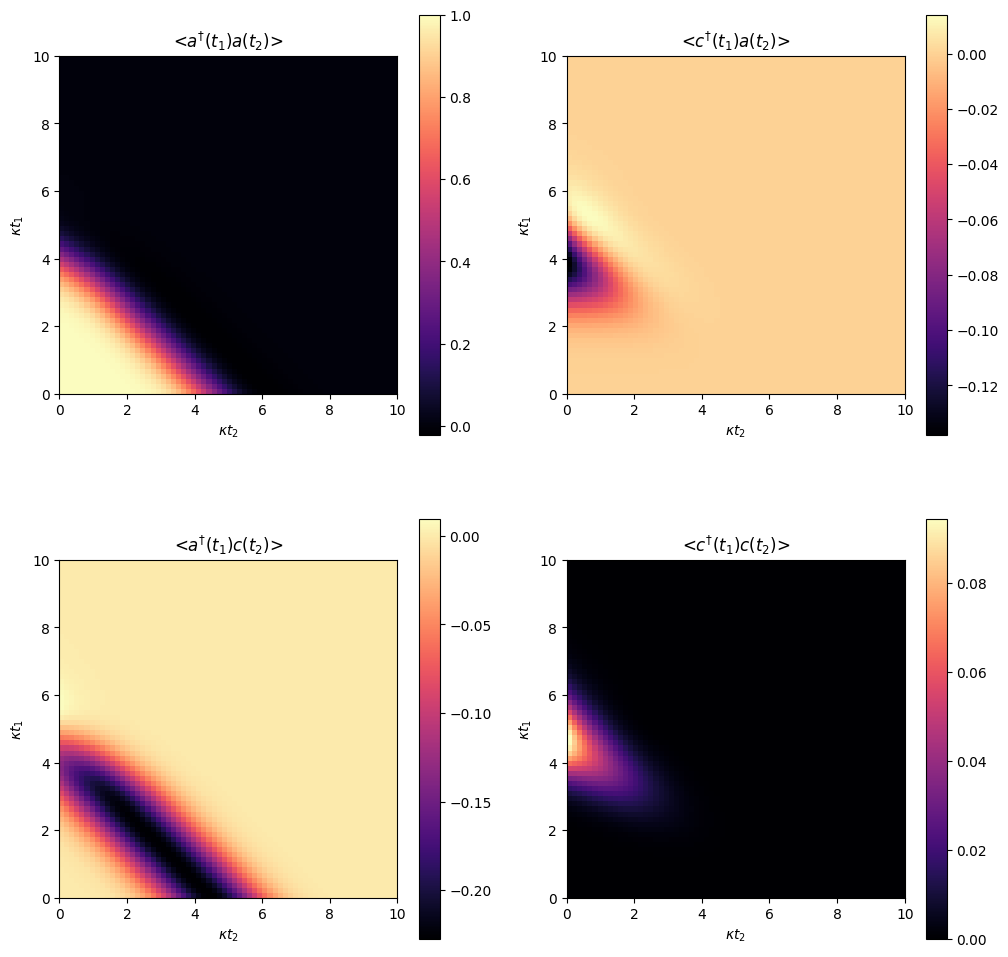

In [62]:
ada = qt.correlation_2op_2t(H_us, psi0, tList, tList, c_ops, aud_input, au_input, reverse=True)
print("finished ada calc")
adc = qt.correlation_2op_2t(H_us, psi0, tList, tList, c_ops, aud_input, c_res, reverse=True) 
print("finished adc calc")
cda = qt.correlation_2op_2t(H_us, psi0, tList, tList, c_ops, cd_res, au_input, reverse=True)
print("finished cda calc")
cdc = qt.correlation_2op_2t(H_us, psi0, tList, tList, c_ops, cd_res, c_res, reverse=True)
print("finished cdc calc")
    
fourPanelPlot(tList, np.real(ada), np.real(adc), np.real(cda), np.real(cdc),
              r'<$a^{\dagger}(t_1)a(t_2)$>', r'<$a^{\dagger}(t_1)c(t_2)$>', r'<$c^{\dagger}(t_1)a(t_2)$>', r'<$c^{\dagger}(t_1)c(t_2)$>')

In [63]:
#prefactors
ID = np.ones((len(tList), len(tList)))
ID1 = np.ones(len(tList))
kappas2 = kappa_ext0*ID
kappag = np.outer(np.sqrt(kappa_ext0)*ID1, [g_u(t, args) for t in tList])
gkappa = np.outer([np.conjugate(g_u(t, args)) for t in tList], np.sqrt(kappa_ext0)*ID1)
gg = np.outer([g_u(t, args) for t in tList], [np.conjugate(g_u(t, args)) for t in tList])

LdL = gg*ada  + kappag*adc + gkappa*cda + kappas2*cdc

AB is not BdAd
AB is not BdAd
AB is not BdAd
AB is not BdAd


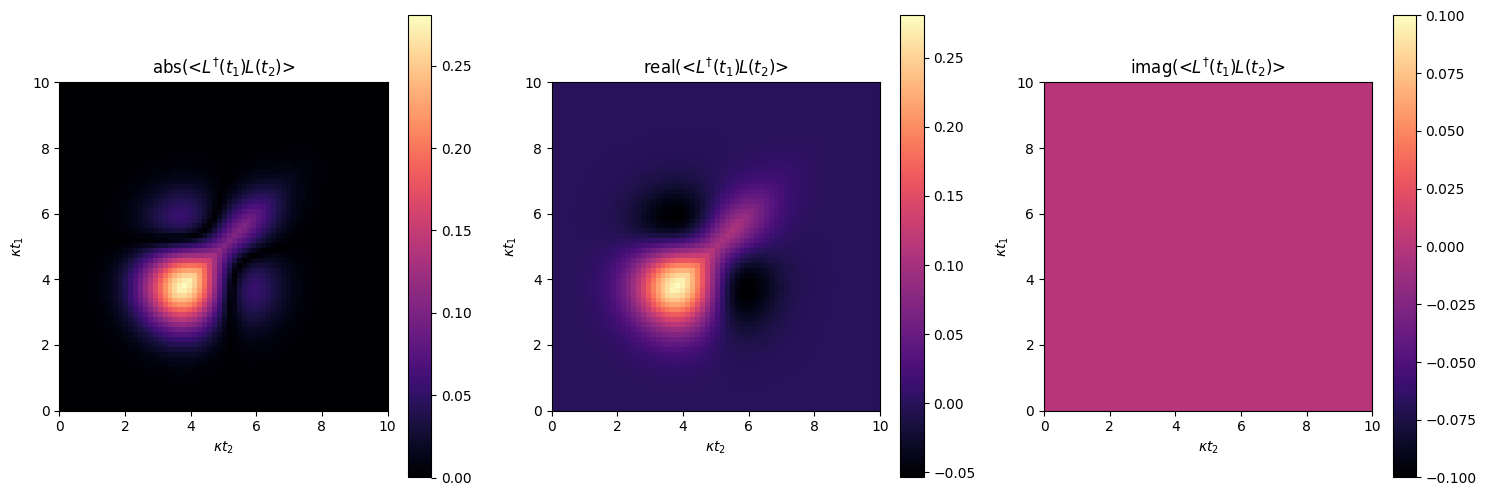

In [64]:
#Use the commutation relations to get aad, ccd
adac = ada.conjugate()
cdcc = cdc.conjugate()

adar = transformMatrixK(1*ada, adac)[0]
cdcr = transformMatrixK(1*cdc, cdcc)[0]
adcr = transformMatrixK(1*adc, 1*cda.conjugate())[0]
cdar = transformMatrixK(1*cda, 1*adc.conjugate())[0]
LdLr =  gg*adar +  gkappa*adcr +  kappag*cdar + kappas2*cdcr

extent = [tList[0], tList[-1], tList[0], tList[-1]]
fig2, axes2 = plt.subplots(1,3, figsize=(18,6))
im20 = axes2[0].imshow(np.abs(LdLr), extent=extent, origin='lower', cmap='magma')
axes2[0].set_title(r'abs(<$L^{\dagger}(t_1)L(t_2)$>')
axes2[0].set_xlim(0, 10)
axes2[0].set_ylim(0, 10)
axes2[0].set_xlabel(r'$\kappa t_2$')
axes2[0].set_ylabel(r'$\kappa t_1$')
plt.colorbar(im20, ax=axes2[0])
im21 = axes2[1].imshow(np.real(LdLr), extent=extent, origin='lower', cmap='magma')
axes2[1].set_title(r'real(<$L^{\dagger}(t_1)L(t_2)$>')
axes2[1].set_xlim(0, 10)
axes2[1].set_ylim(0, 10)
axes2[1].set_xlabel(r'$\kappa t_2$')
axes2[1].set_ylabel(r'$\kappa t_1$')
plt.colorbar(im21, ax=axes2[1])
im22 = axes2[2].imshow(np.imag(LdLr), extent=extent, origin='lower', cmap='magma')
axes2[2].set_title(r'imag(<$L^{\dagger}(t_1)L(t_2)$>')
axes2[2].set_xlim(0, 10)
axes2[2].set_ylim(0, 10)
axes2[2].set_xlabel(r'$\kappa t_2$')
axes2[2].set_ylabel(r'$\kappa t_1$')
plt.colorbar(im22, ax=axes2[2])


c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


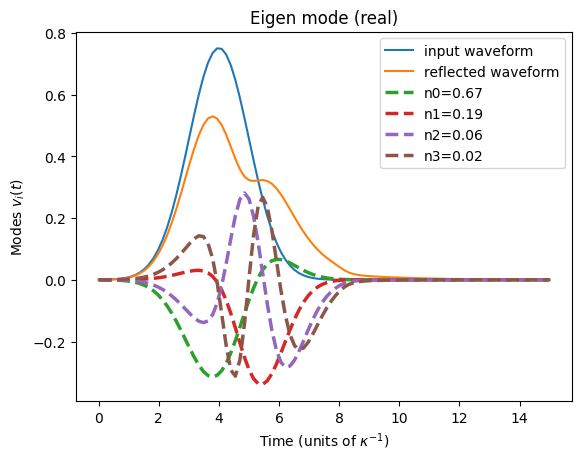

In [116]:
eigvals, eigvecs = eigh(LdLr, type=1)

#Sort by size of eigenvalue
sortOrder = np.argsort(np.real(eigvals))[::-1]
valsSorted = eigvals[sortOrder]
vecsSorted = eigvecs[:, sortOrder]
eigvals_normalized = valsSorted / np.sum(np.abs(valsSorted)) 

fig, axes = plt.subplots()
axes.plot(tList, uGauss(tList, driveFuncArgs), label='input waveform')
axes.plot(tList, np.sqrt(np.diagonal(LdLr)), label='reflected waveform')
for i in range(4):
    eigenmode = interp.interp1d(tList, vecsSorted[:,i], kind='cubic', bounds_error=False, fill_value=0)
    axes.plot(tList, np.real(eigenmode(tList)), lw=2.5, linestyle='--', label='n'+str(i)+'='+str(np.round(eigvals_normalized[i], 2)))
axes.set_title(r'Eigen mode (real)')
axes.set_xlabel(r'Time (units of $\kappa^{-1}$)')
axes.set_ylabel(r'Modes $v_i(t)$')
axes.legend()